# Carbonate sensitivity maps: $\beta$ and $\eta$ for DOR & OAE experiments

In [38]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from plot import _plot_field, _plot_colorbar, _finish_panel, _diff_limits, compute_zoom_box, get_label_string, ZOOM_COORDS, _draw_zoom_box, DEFAULT_ZOOM_CITIES

In [39]:
scenarios = {
    "dor": {
        "base_dir": "roms_marbl_dic",
        "title": "DOR",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\ominus"},
            "JP7":  {"label": r"\mathrm{J100}\!\ominus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\ominus"},
            "VI10": {"label": r"\mathrm{V10}\!\ominus"},
            "VI7":  {"label": r"\mathrm{V100}\!\ominus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\ominus"},
            "BC10": {"label": r"\mathrm{B10}\!\ominus"},
            "BC7":  {"label": r"\mathrm{B100}\!\ominus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\ominus"},
            "EC10": {"label": r"\mathrm{E10}\!\ominus"},
            "EC7":  {"label": r"\mathrm{E100}\!\ominus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\ominus"},
        },
    },
    "oae": {
        "base_dir": "roms_marbl_alk",
        "title": "OAE",
        "exps": {
            "JP10": {"label": r"\mathrm{J10}\!\oplus"},
            "JP7":  {"label": r"\mathrm{J100}\!\oplus"},
            "JP8":  {"label": r"\mathrm{J1000}\!\oplus"},
            "VI10": {"label": r"\mathrm{V10}\!\oplus"},
            "VI7":  {"label": r"\mathrm{V100}\!\oplus"},
            "VI8":  {"label": r"\mathrm{V1000}\!\oplus"},
            "BC10": {"label": r"\mathrm{B10}\!\oplus"},
            "BC7":  {"label": r"\mathrm{B100}\!\oplus"},
            "BC8":  {"label": r"\mathrm{B1000}\!\oplus"},
            "EC10": {"label": r"\mathrm{E10}\!\oplus"},
            "EC7":  {"label": r"\mathrm{E100}\!\oplus"},
            "EC8":  {"label": r"\mathrm{E1000}\!\oplus"},
        },
    },
}

In [40]:
locations = ["JP", "VI", "BC", "EC"]
amplitudes = {"10": "10", "7": "100", "8": "1000"}

# Centralized in plot.py (ZOOM_COORDS) so it only needs editing in one place.
zoom_coords = {loc: ZOOM_COORDS[loc] for loc in locations}


variables = {
    "beta": {"key": "dDICdCO2", "symbol": r"\beta", "cmap_ctrl": "inferno", "cmap_diff": "RdBu_r"},
    "eta":  {"key": "dDICdALK", "symbol": r"\eta",  "cmap_ctrl": "viridis", "cmap_diff": "RdBu_r"},
}

## Data loading

In [41]:
from roms_tools import Grid

grid_file = "roms_marbl_dic/expCTRL/pacmed12_grd.nc"
grid = Grid.from_file(grid_file, theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

lon = grid.ds["lon_rho"]
lat = grid.ds["lat_rho"]

2026-09-14 05:06:26 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-09-14 05:06:26 - INFO - Total time: 0.003 seconds
2026-09-14 05:06:26 - INFO - ================================================================================================


In [42]:
def load_ctrl_beta(ctrl_dir="roms_marbl_dic/expCTRL/BETA"):
    return xr.open_mfdataset(
        f"{ctrl_dir}/carbonate_sensitivity_2000*.nc",
        combine="nested",
        concat_dim="time",
    )

def load_exp_beta(base_dir, exp):
    suffix = "_perlmutter" if base_dir == "roms_marbl_alk" and exp.endswith("8") else ""
    return xr.open_mfdataset(
        f"{base_dir}/exp{exp}{suffix}/OUTPUT/BETA/carbonate_sensitivity*.nc",
        combine="nested",
        concat_dim="time",
    )

In [43]:
ds_ctrl = load_ctrl_beta()

for scenario_key, scen in scenarios.items():
    base_dir = scen["base_dir"]
    scen["beta_data"] = {}
    for exp in scen["exps"]:
        try:
            scen["beta_data"][exp] = load_exp_beta(base_dir, exp)
        except (FileNotFoundError, OSError):
            print(f"[SKIP] No BETA data for {base_dir}/exp{exp}")

In [44]:
# Release centers from grid indices defined in make_tracer_surface_flux.ipynb
_release_indices = {
    "JP": (710, 459),
    "VI": (855, 1135),
    "BC": (650, 1290),
    "EC": (490, 1640),
}
release_centers = {
    loc: (float(lon[eta, xi]), float(lat[eta, xi]))
    for loc, (eta, xi) in _release_indices.items()
}

In [45]:
def _onesided_diff_limits(field_zoom, cb_overrides, key, var_key):
    """One-sided colorbar limits: beta anchored at vmin=0, eta anchored at vmax=0.

    `key` indexes cb_overrides (a location, experiment name, or var_key itself,
    depending on caller); `var_key` ("beta"/"eta") picks which side is the fixed
    zero anchor.
    """
    overrides = cb_overrides.get(key, {})
    if var_key == "beta":
        vmin = overrides.get("vmin", 0)
        vmax = overrides.get("vmax", float(field_zoom.max(skipna=True)))
    else:
        vmin = overrides.get("vmin", float(field_zoom.min(skipna=True)))
        vmax = overrides.get("vmax", 0)
    return vmin, vmax


def _onesided_diff_extend(field_zoom, vmin, vmax, var_key):
    """Extend arrow for a one-sided diff colorbar.

    The side anchored at zero never extends: pcolormesh already clips out-of-range
    values into the edge color, and an arrow there would misleadingly suggest
    off-scale data on the "wrong" side of the anchor. Only the data-driven side can
    extend, and only past an explicit override (the default bound already equals
    field_zoom's actual min/max).
    """
    if var_key == "beta":
        return "max" if float(field_zoom.max(skipna=True)) > vmax else "neither"
    else:
        return "min" if float(field_zoom.min(skipna=True)) < vmin else "neither"


def _max_magnitude_label(field_zoom, digits):
    """Like get_label_string, but with a fixed number of digits after the decimal point
    (via %.{digits}f) instead of get_label_string's 3-significant-figure format."""
    max_val = float(np.abs(field_zoom).max(skipna=True))
    return f"Max Magnitude = {max_val:.{digits}f}"

## Relative difference: $\beta$ (first column) and $\eta$ (second column)

In [46]:
def plot_rel_diff_2x4(
    ds_ctrl, scen, amp_suffix, time_idx,
    figsize=(10, 14),
    beta_colorbar_overrides=None,
    eta_colorbar_overrides=None,
    release_centers=None,
    nr_digits=1,
    panel_labels=("a", "b", "c", "d", "e", "f", "g", "h"),
):
    """4x2 figure: (ctrl-exp)/exp*100 for beta (left col) and eta (right col).

    Layout (row, col):
        (0,0) JP beta   (0,1) JP eta
        (1,0) VI beta   (1,1) VI eta
        (2,0) BC beta   (2,1) BC eta
        (3,0) EC beta   (3,1) EC eta

    beta_colorbar_overrides / eta_colorbar_overrides : dict, optional
        Keyed by exp_name (e.g. "JP8") -> {"vmin": ..., "vmax": ...}.
        One-sided limits: beta anchored at vmax=0, eta at vmin=0.
    """
    beta_colorbar_overrides = beta_colorbar_overrides or {}
    eta_colorbar_overrides  = eta_colorbar_overrides  or {}
    # Sign-flipped: beta (ctrl-exp)/exp < 0 for OAE → Blues_r (vmax=0)
    #               eta  (ctrl-exp)/exp > 0 for OAE → Reds    (vmin=0)
    var_cmaps    = {"beta": "Blues_r", "eta": "Reds"}
    # _onesided_diff_limits uses "beta" for vmin=0 and "eta" for vmax=0;
    # after sign flip the roles swap, so pass the opposite key.
    lim_var_keys = {"beta": "eta", "eta": "beta"}

    fig, axs = plt.subplots(nrows=4, ncols=2, figsize=figsize)

    for row, loc in enumerate(locations):
        zc = zoom_coords[loc]
        lon_min, lon_max = zc["lon_min"], zc["lon_max"]
        lat_min, lat_max = zc["lat_min"], zc["lat_max"]
        proj = ccrs.LambertConformal(
            central_longitude=(lon_min + lon_max) / 2,
            central_latitude=(lat_min + lat_max) / 2,
        )
        lon_min_adj = lon_min - 360 if lon_min > 0 else lon_min
        lon_max_adj = lon_max - 360 if lon_max > 0 else lon_max
        mask = (
            (lon >= lon_min_adj) & (lon <= lon_max_adj)
            & (lat >= lat_min) & (lat <= lat_max)
        )

        exp_name = f"{loc}{amp_suffix}"

        for col, var_key in enumerate(["beta", "eta"]):
            axs[row, col].remove()
            ax = fig.add_subplot(4, 2, row * 2 + col + 1, projection=proj)

            var = variables[var_key]
            field_name = var["key"]
            symbol = var["symbol"]
            cb_overrides = beta_colorbar_overrides if var_key == "beta" else eta_colorbar_overrides
            lim_var = lim_var_keys[var_key]
            diff_cmap = var_cmaps[var_key]

            ctrl_field = ds_ctrl[field_name].isel(time=time_idx)
            plabel = panel_labels[row * 2 + col]
            label_exp = scen["exps"][exp_name]["label"]

            if exp_name in scen["beta_data"]:
                exp_field = scen["beta_data"][exp_name][field_name].isel(time=time_idx)
                rel_diff = -(exp_field - ctrl_field) / exp_field * 100
                rel_zoom = rel_diff.where(mask)
                vmin_diff, vmax_diff = _onesided_diff_limits(rel_zoom, cb_overrides, exp_name, lim_var)
                extend = _onesided_diff_extend(rel_zoom, vmin_diff, vmax_diff, lim_var)
                p = ax.pcolormesh(lon, lat, rel_diff, transform=ccrs.PlateCarree(),
                                  cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
                _plot_colorbar(fig, ax, p, rel_zoom, vmax_diff, vmin_diff,
                               orientation="vertical", shrink=0.85, pad=0.02,
                               label="%", extend=extend)
                ax.text(0.5, 0.05, _max_magnitude_label(rel_zoom, nr_digits),
                        transform=ax.transAxes, ha="center", va="center", fontsize=11)
            else:
                ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                        ha="center", va="center", fontsize=14, color="gray")

            title = (
                rf"({plabel}) $({symbol}_\mathtt{{REF}} - {symbol}_{{{label_exp}}})"
                rf" / {symbol}_{{{label_exp}}} \times 100$"
            )
            ax.set_title(title, fontsize=11)
            _finish_panel(ax, lon_min, lon_max, lat_min, lat_max, loc, release_centers)

    plt.tight_layout(h_pad=1, w_pad=1)
    return fig

In [47]:
amp_suffix = "8"
time_idx = 182  # 2000-07-01

beta_cb = {
    "JP8": {"vmin": -2, "vmax": 0},
    "VI8": {"vmin": -25, "vmax": 0},
    "BC8": {"vmin": -10, "vmax": 0},
    "EC8": {"vmin": -10, "vmax": 0},
}
eta_cb = {
    "JP8": {"vmin": 0, "vmax": 0.2},
    "VI8": {"vmin": 0, "vmax": 2},
    "BC8": {"vmin": 0, "vmax": 1.0},
    "EC8": {"vmin": 0, "vmax": 1.0},
}

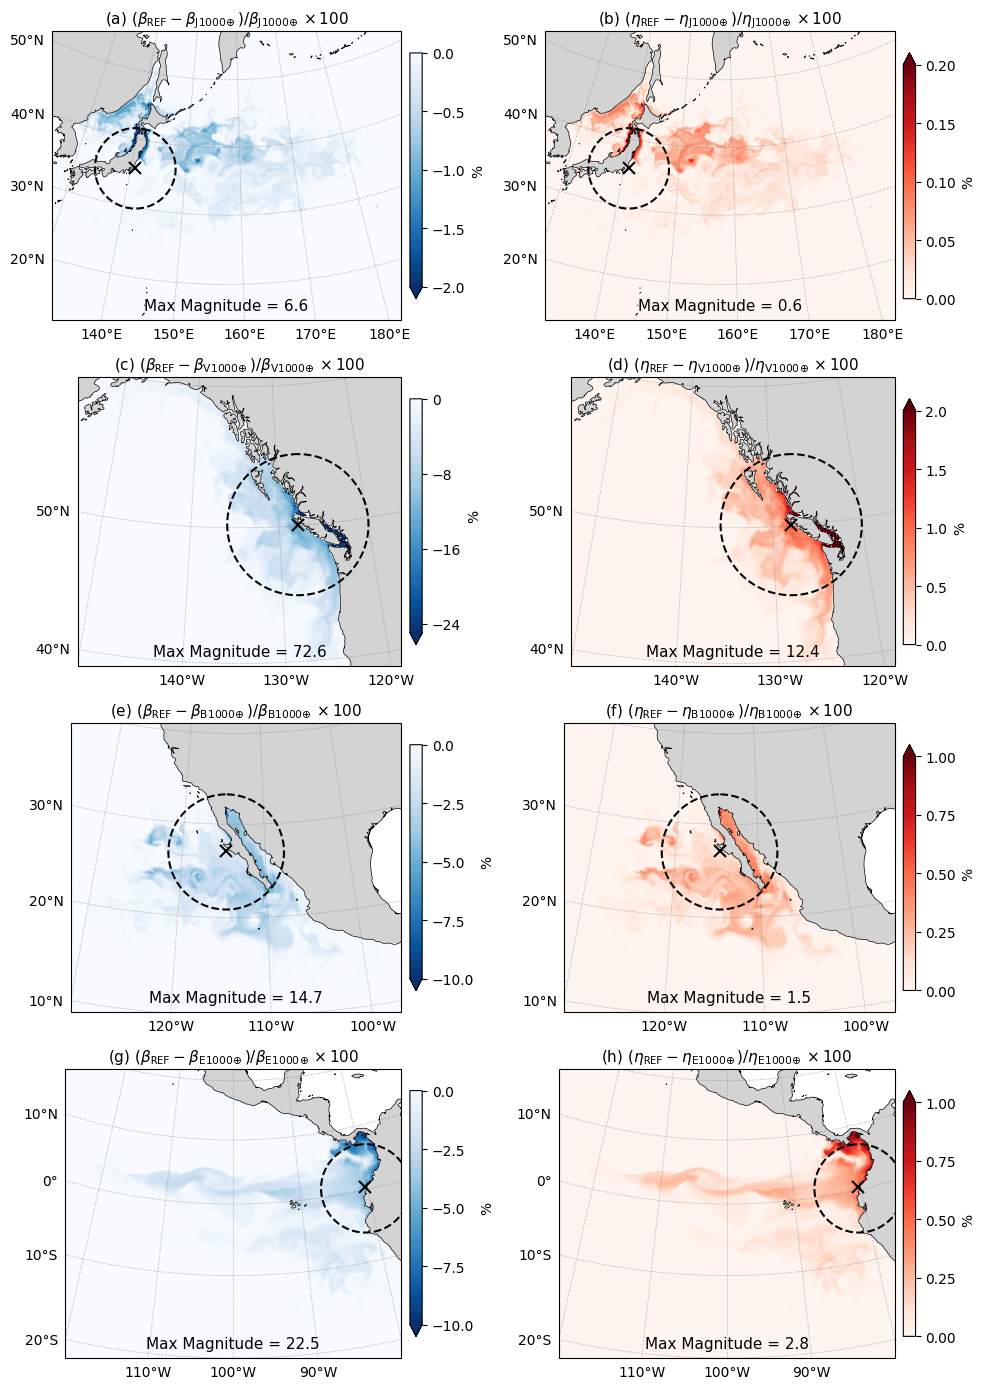

In [25]:
fig = plot_rel_diff_2x4(
    ds_ctrl, scenarios["oae"], amp_suffix, time_idx,
    beta_colorbar_overrides=beta_cb,
    eta_colorbar_overrides=eta_cb,
    release_centers=release_centers,
)

In [26]:
fig.savefig(f"figures/beta_eta_oae_{amp_suffix}_{time_idx}_rel_diff_2x4.png", dpi=300, bbox_inches="tight")

## $\beta$ (4×2, one amplitude across all locations)

In [58]:
def plot_sensitivity_4x2(ds_ctrl, scen, var_key, amp_suffix, time_idx,
                         figsize=(9, 13),
                         colorbar_overrides=None,
                         ctrl_colorbar_overrides=None,
                         release_centers=None,
                         nr_digits=1,
                         relative=False):
    """4×2 figure: one row per location, left=ctrl, right=ctrl-exp.

    The diff panel uses a one-sided colormap anchored at zero: Reds (vmin=0) for beta,
    Blues_r (vmax=0) for eta, matching plot_overview_2x3's convention. The colorbar's
    extend arrow never crosses that zero anchor -- only the data-driven side can extend.
    It is annotated with a max-magnitude label instead of min/max, also matching
    plot_overview_2x3.

    Parameters
    ----------
    colorbar_overrides : dict, optional
        Maps exp_name -> {"vmin": ..., "vmax": ...} to override the diff colorbar's
        zero-anchored bound (normally 0) and/or its data-driven bound.
    ctrl_colorbar_overrides : dict, optional
        Maps loc -> {"vmin": ..., "vmax": ...} to override ctrl colorbar limits.
    release_centers : dict, optional
        Maps loc -> (lon, lat) for X marker and a circle overlay enclosing 90% of that
        site's actual Gaussian release footprint (see plot.py: RELEASE_SIGMA_KM).
    nr_digits : int
        Decimal places in the ctrl panel's min/max annotation and the diff panel's
        max-magnitude annotation. Default 2.
    relative : bool
        If True, the right panel shows (ctrl - exp) / exp * 100
        instead of the absolute difference ctrl - exp. Default False.
    """
    var = variables[var_key]
    field_name = var["key"]
    symbol = var["symbol"]
    diff_cmap = {"beta": "Blues_r", "eta": "Reds"}[var_key]
    rel_diff_cmap = {"beta": "Blues_r", "eta": "Reds"}[var_key]
    colorbar_overrides = colorbar_overrides or {}
    ctrl_colorbar_overrides = ctrl_colorbar_overrides or {}
    # Eta's ctrl panel uses the viridis colormap, dark enough at low values that black
    # min/max text is hard to read there; beta's ctrl panel (inferno) keeps black text.
    ctrl_text_color = "white" if var_key == "eta" else "black"

    ctrl_field = ds_ctrl[field_name].isel(time=time_idx)
    nrows = len(locations)
    fig, axs = plt.subplots(nrows=nrows, ncols=2, figsize=figsize)

    for i, loc in enumerate(locations):
        zc = zoom_coords[loc]
        lon_min, lon_max = zc["lon_min"], zc["lon_max"]
        lat_min, lat_max = zc["lat_min"], zc["lat_max"]
        proj = ccrs.LambertConformal(
            central_longitude=(lon_min + lon_max) / 2,
            central_latitude=(lat_min + lat_max) / 2,
        )
        for j in range(2):
            axs[i, j].remove()
            axs[i, j] = fig.add_subplot(nrows, 2, 2 * i + j + 1, projection=proj)

        lon_min_adj = lon_min - 360 if lon_min > 0 else lon_min
        lon_max_adj = lon_max - 360 if lon_max > 0 else lon_max
        mask = (lon >= lon_min_adj) & (lon <= lon_max_adj) & (lat >= lat_min) & (lat <= lat_max)
        ctrl_zoom = ctrl_field.where(mask)

        # Left panel: ctrl
        overrides = ctrl_colorbar_overrides.get(loc, {})
        vmin_data = float(ctrl_zoom.min(skipna=True))
        vmax_data = float(ctrl_zoom.max(skipna=True))
        vmin_ctrl = overrides.get("vmin", vmin_data)
        vmax_ctrl = overrides.get("vmax", vmax_data)
        _plot_field(fig, axs[i, 0], lon, lat, ctrl_field, ctrl_zoom,
                    var["cmap_ctrl"], vmin_ctrl, vmax_ctrl, nr_digits, fontsize=11,
                    text_color=ctrl_text_color)
        axs[i, 0].set_title(rf"({chr(ord('a') + 2 * i)}) ${symbol}_\mathtt{{REF}}$")
        _finish_panel(axs[i, 0], lon_min, lon_max, lat_min, lat_max, loc, release_centers)

        # Right panel: ctrl - exp (or relative change if relative=True)
        exp_name = f"{loc}{amp_suffix}"
        label = scen["exps"][exp_name]["label"]
        if relative:
            title = rf"({chr(ord('a') + 2 * i + 1)}) $({symbol}_\mathtt{{REF}} - {symbol}_{{{label}}}) / {symbol}_{{{label}}} \times 100$"
        else:
            title = rf"({chr(ord('a') + 2 * i + 1)}) ${symbol}_\mathtt{{REF}} - {symbol}_{{{label}}}$"
        axs[i, 1].set_title(title)
        if exp_name in scen["beta_data"]:
            exp_field = scen["beta_data"][exp_name][field_name].isel(time=time_idx)
            diff = ctrl_field - exp_field
            if relative:
                diff = diff / exp_field * 100
            diff_zoom = diff.where(mask)
            _lim_var = "eta" if var_key == "beta" else "beta"
            vmin_diff, vmax_diff = _onesided_diff_limits(diff_zoom, colorbar_overrides, exp_name, _lim_var)
            extend = _onesided_diff_extend(diff_zoom, vmin_diff, vmax_diff, _lim_var)
            ax = axs[i, 1]
            _cmap = rel_diff_cmap if relative else diff_cmap
            p = ax.pcolormesh(lon, lat, diff, transform=ccrs.PlateCarree(),
                              cmap=_cmap, vmin=vmin_diff, vmax=vmax_diff)
            _plot_colorbar(fig, ax, p, diff_zoom, vmax_diff, vmin_diff,
                           orientation="vertical", shrink=0.85, pad=0.02,
                           label="%" if relative else "", extend=extend)
            ax.text(0.5, 0.05, _max_magnitude_label(diff_zoom, nr_digits),
                    transform=ax.transAxes, ha="center", va="center", fontsize=11)
        else:
            axs[i, 1].text(0.5, 0.5, "No data", transform=axs[i, 1].transAxes,
                           ha="center", va="center", fontsize=14, color="gray")
        _finish_panel(axs[i, 1], lon_min, lon_max, lat_min, lat_max, loc, release_centers)

    plt.tight_layout(h_pad=1, w_pad=1)
    return fig

In [59]:
time_idx = 182 # 2000-07-01

## Relative differences

In [60]:
amp_suffix = "8"
colorbar_overrides = {
    "JP8": {"vmin": -3, "vmax": 0},
    "VI8": {"vmin": -30, "vmax": 0},
    "BC8": {"vmin": -12, "vmax": 0},
    "EC8": {"vmin": -12, "vmax": 0}
}
ctrl_colorbar_overrides = {
    "VI": {"vmin": 8, "vmax": 16},
    "EC": {"vmin": 10, "vmax": 26}
}

### OAE

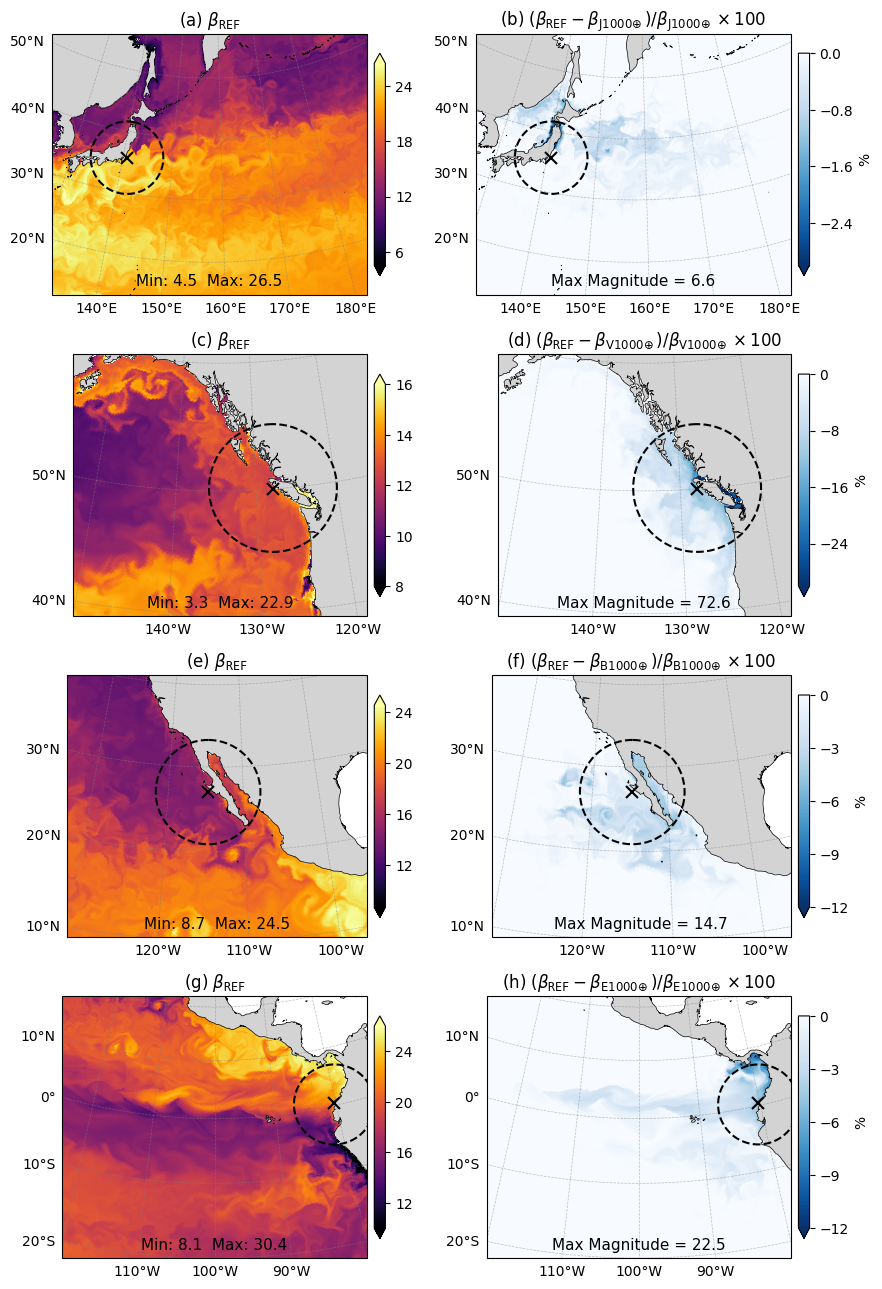

In [61]:
fig = plot_sensitivity_4x2(ds_ctrl, scenarios["oae"], "beta", amp_suffix, time_idx, release_centers=release_centers, colorbar_overrides=colorbar_overrides, ctrl_colorbar_overrides=ctrl_colorbar_overrides, relative=True)

In [62]:
fig.savefig(f"figures/beta_oae_{amp_suffix}_{time_idx}_rel_diff.png", dpi=300, bbox_inches="tight")

### DOR

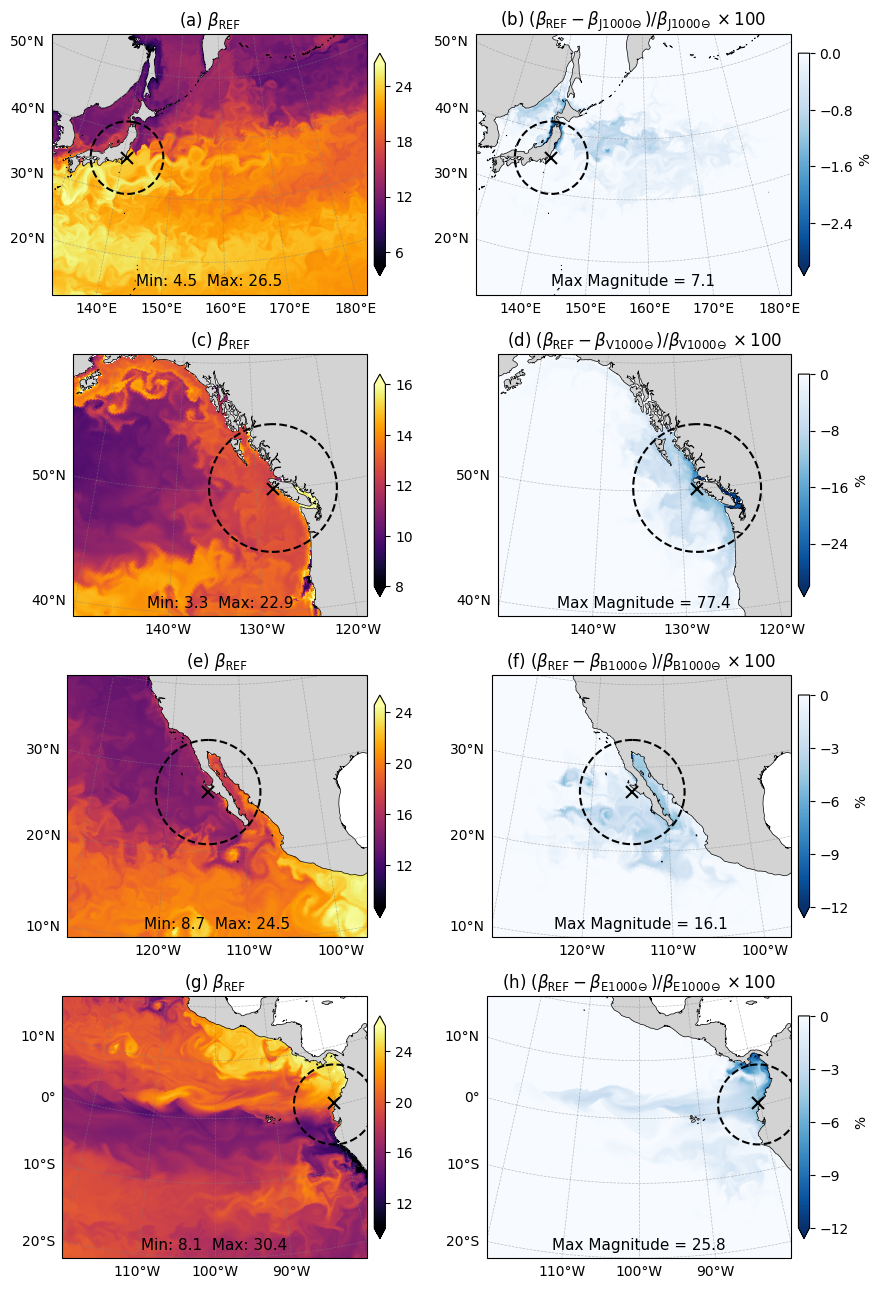

In [33]:
fig = plot_sensitivity_4x2(ds_ctrl, scenarios["dor"], "beta", amp_suffix, time_idx, release_centers=release_centers, colorbar_overrides=colorbar_overrides, ctrl_colorbar_overrides=ctrl_colorbar_overrides, relative=True)

In [34]:
fig.savefig(f"figures/beta_dor_{amp_suffix}_{time_idx}_rel_diff.png", dpi=300, bbox_inches="tight")

## Absolute differences

In [ ]:
amp_suffix = "8"
colorbar_overrides = {
    "JP8": {"vmin": -0.5, "vmax": 0},
    "VI8": {"vmin": -5, "vmax": 0},
    "BC8": {"vmin": -2, "vmax": 0},
    "EC8": {"vmin": -2, "vmax": 0}
}
ctrl_colorbar_overrides = {
    "VI": {"vmin": 8, "vmax": 16},
    "EC": {"vmin": 10, "vmax": 26}
}

### OAE

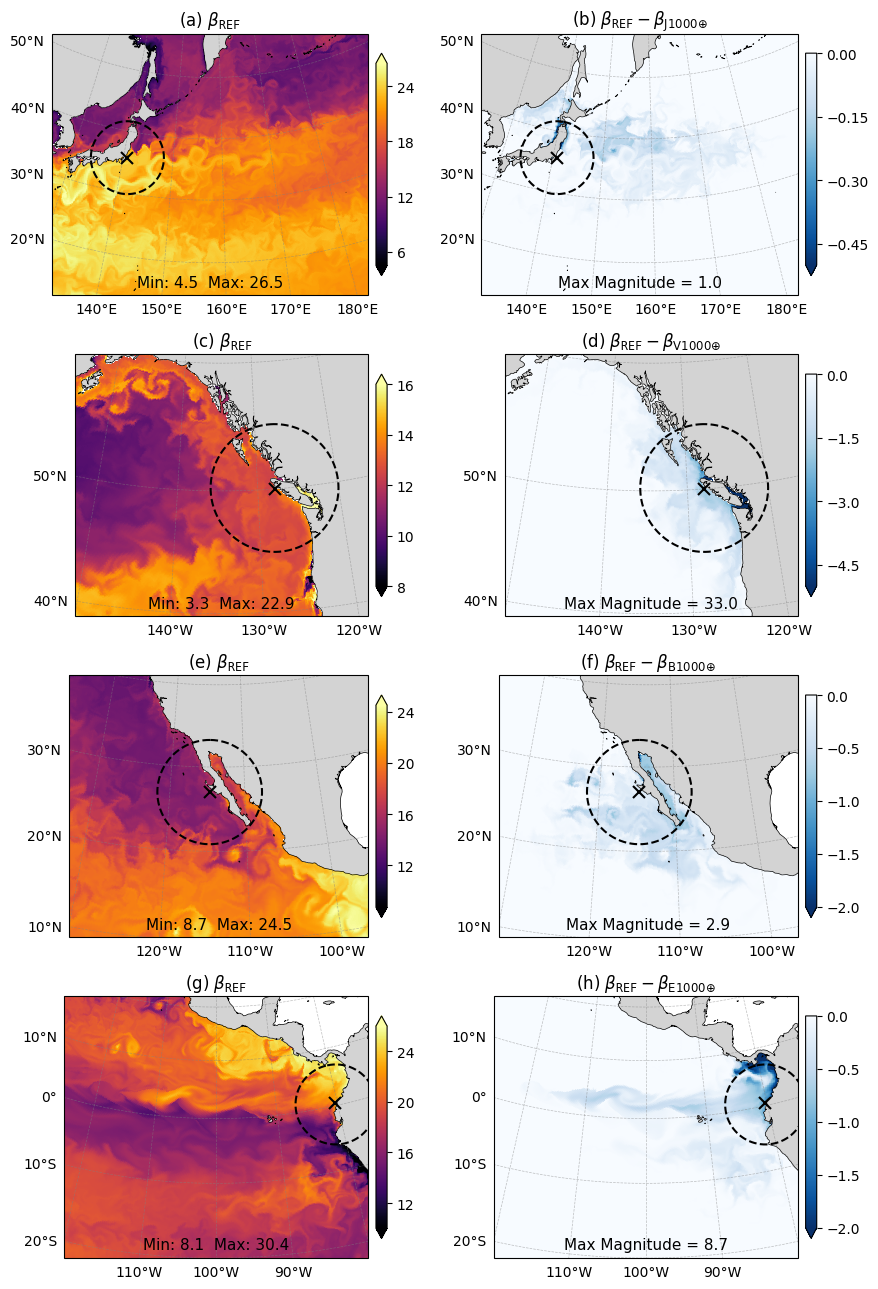

In [36]:
fig = plot_sensitivity_4x2(ds_ctrl, scenarios["oae"], "beta", amp_suffix, time_idx, release_centers=release_centers, colorbar_overrides=colorbar_overrides, ctrl_colorbar_overrides=ctrl_colorbar_overrides)

In [37]:
fig.savefig(f"figures/beta_oae_{amp_suffix}_{time_idx}_abs_diff.png", dpi=300, bbox_inches="tight")

### DOR

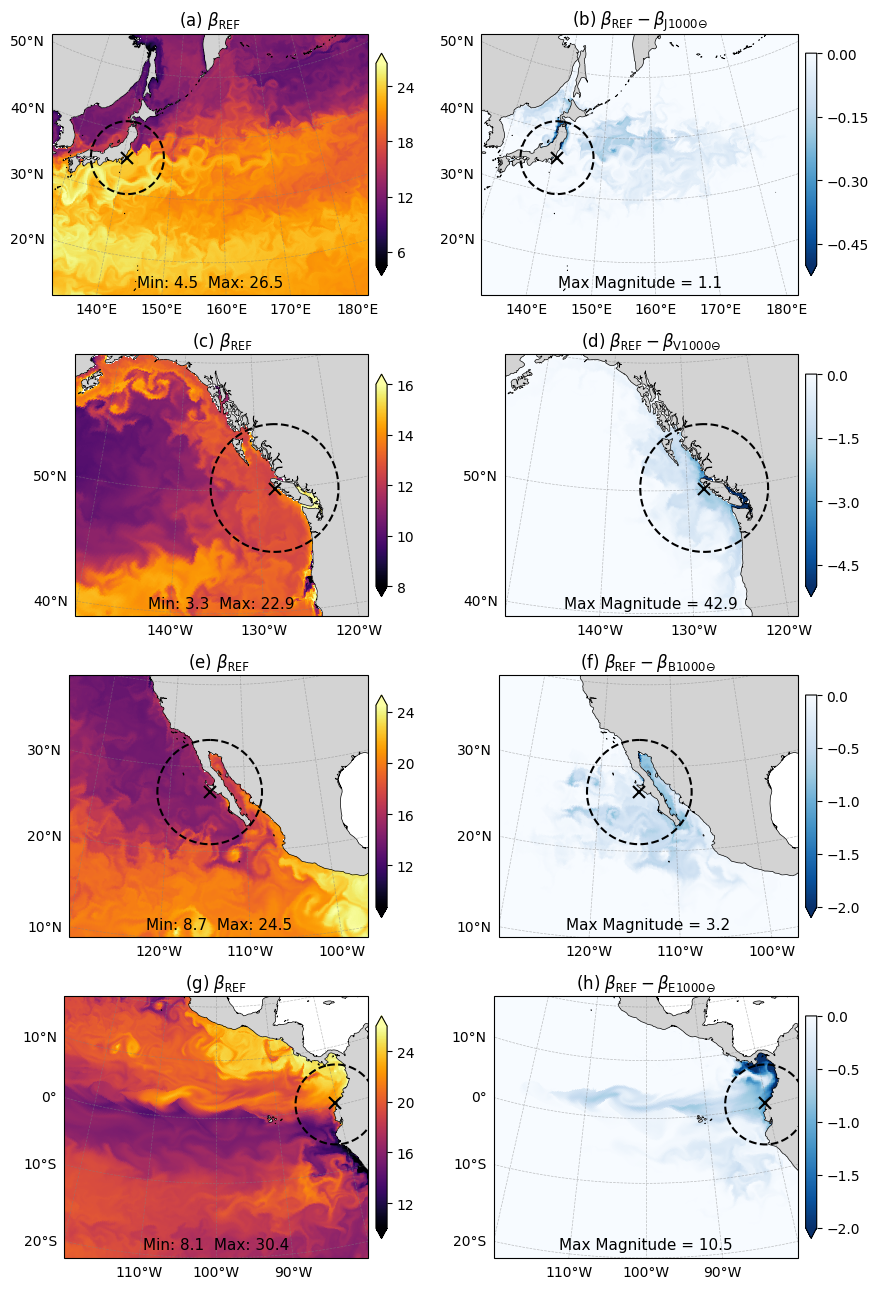

In [38]:
fig = plot_sensitivity_4x2(ds_ctrl, scenarios["dor"], "beta", amp_suffix, time_idx, release_centers=release_centers, colorbar_overrides=colorbar_overrides, ctrl_colorbar_overrides=ctrl_colorbar_overrides)

In [39]:
fig.savefig(f"figures/beta_dor_{amp_suffix}_{time_idx}_abs_diff.png", dpi=300, bbox_inches="tight")

## $\eta$ (4×2, one amplitude across all locations)

## Relative differences

In [52]:
amp_suffix = "8"
colorbar_overrides = {
    "JP8": {"vmin": 0, "vmax": 0.1},
    "VI8": {"vmin": 0, "vmax": 1.2},
    "BC8": {"vmin": 0, "vmax": 0.6},
    "EC8": {"vmin": 0, "vmax": 1.0}
}

### OAE

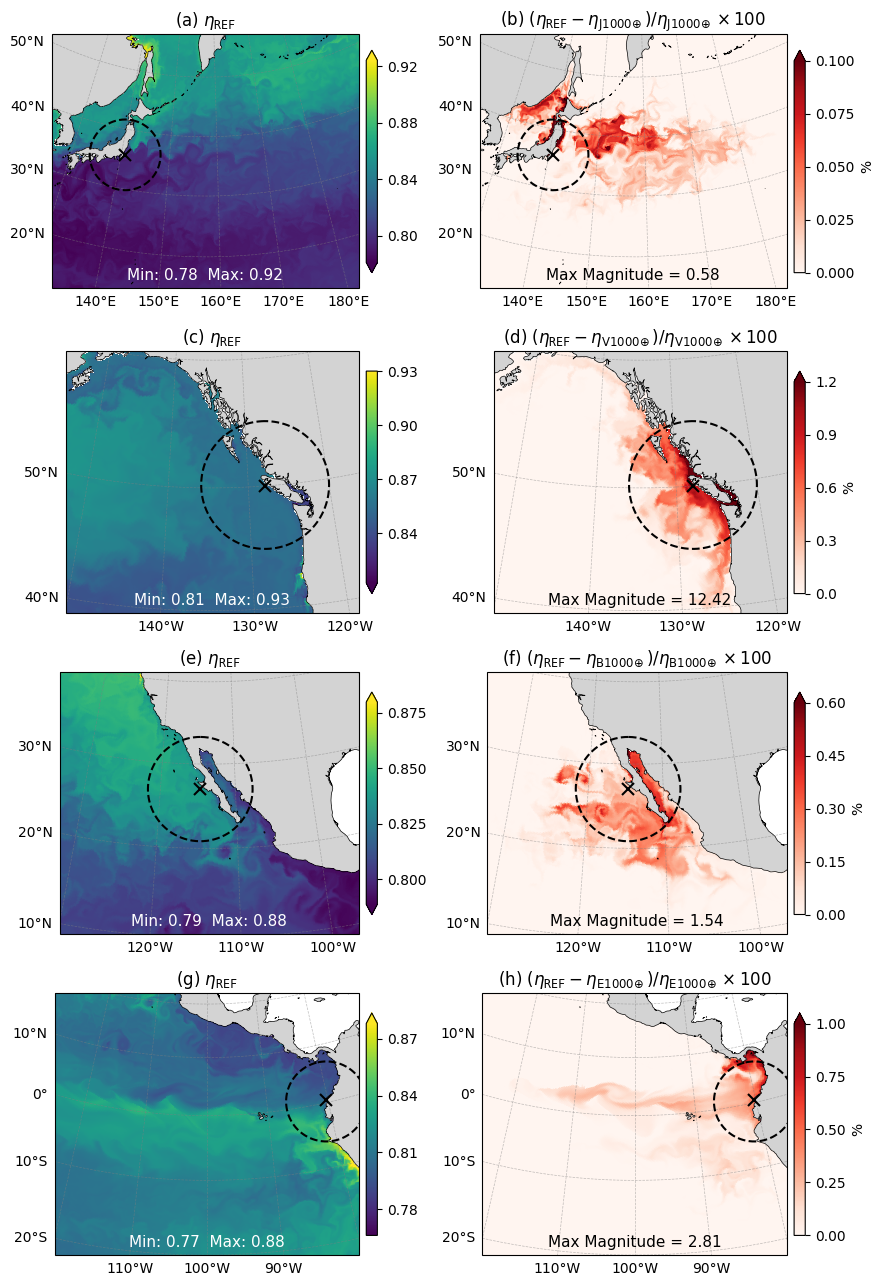

In [53]:
fig = plot_sensitivity_4x2(ds_ctrl, scenarios["oae"], "eta", amp_suffix, time_idx, release_centers=release_centers, colorbar_overrides=colorbar_overrides, nr_digits=2, relative=True)

In [54]:
fig.savefig(f"figures/eta_oae_{amp_suffix}_{time_idx}_rel_diff.png", dpi=300, bbox_inches="tight")

## Absolute differences

In [55]:
amp_suffix = "8"
colorbar_overrides = {
    "JP8": {"vmin": 0, "vmax": 0.001},
    "VI8": {"vmin": 0, "vmax": 0.01},
    "BC8": {"vmin": 0, "vmax": 0.005},
    "EC8": {"vmin": 0, "vmax": 0.005}
}

### OAE

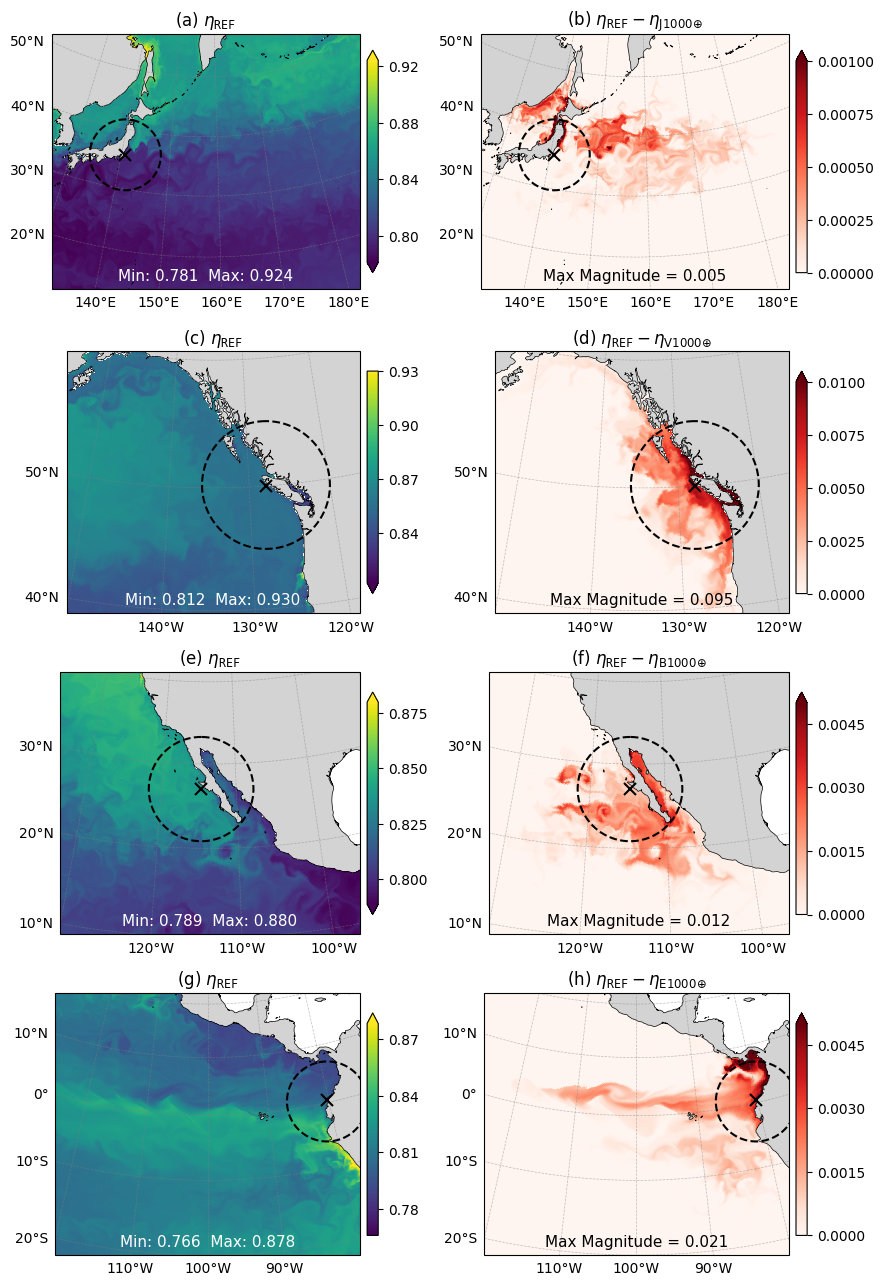

In [56]:
fig = plot_sensitivity_4x2(ds_ctrl, scenarios["oae"], "eta", amp_suffix, time_idx, release_centers=release_centers, colorbar_overrides=colorbar_overrides, nr_digits=3)

In [57]:
fig.savefig(f"figures/eta_oae_{amp_suffix}_{time_idx}_abs_diff.png", dpi=300, bbox_inches="tight")